<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict, defaultdict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare technologies

In [3]:
dataset_name = "parse_10x"  # options: parse_10x, smartseq_10x
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 8  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata_10x_url, adata_parse_url, adata_smartseq_url = None, None, None
adata_path_raw_10x = os.path.join(data_dir, "adata_10x_raw.h5ad")
adata_path_parse = os.path.join(data_dir, "adata_parse_raw.h5ad")
adata_path_smartseq = os.path.join(data_dir, "adata_smartseq_raw.h5ad")

technology_to_adata_raw, technology_to_adata_raw_path = {}, {}
if dataset_name == "parse_10x":
    technologies = ["10x", "parse"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/g03q46wpr5uj81gqp0dh3dyy02zw200e.h5ad"
    adata_parse_url = "https://caltech.box.com/shared/static/4bai2qfe7xk2956ug1t7bpdw0q6tspie.h5ad"

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}

    if not os.path.exists(adata_path_parse):
        !wget -O {adata_path_parse} {adata_parse_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["parse"] = adata_path_parse

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["parse"] = ad.read_h5ad(adata_path_parse)

    technology_to_umi_cutoff = {
        "10x": 300,
        "parse": 200,
    }
    technology_to_leiden_resolution = {
        "10x": 2.0,
        "parse": 2.5
    }

elif dataset_name == "smartseq_10x":
    technologies = ["10x", "smartseq"]
    
    adata_10x_url = ""
    adata_smartseq_url = ""

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}
    
    if not os.path.exists(adata_path_smartseq):
        !wget -O {adata_path_smartseq} {adata_smartseq_url}
    
    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["smartseq"] = adata_path_smartseq

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["smartseq"] = ad.read_h5ad(adata_path_smartseq)

    technology_to_umi_cutoff = {
        "10x": None,
        "smartseq": None,
    }
    technology_to_leiden_resolution = {
        "10x": 1.0,
        "smartseq": 1.0
    }
else:
    raise ValueError(f"dataset_name {dataset_name} not recognized.")

technology0, technology1 = technologies[0], technologies[1]

## Knee plot - use this output to estimate umi_cutoff

Processing technology: 10x
Processing technology: parse


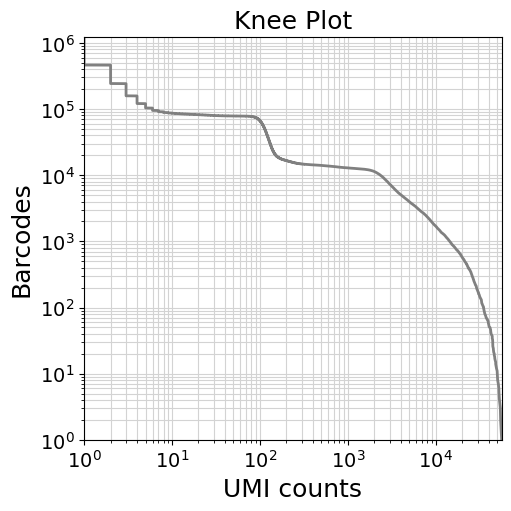

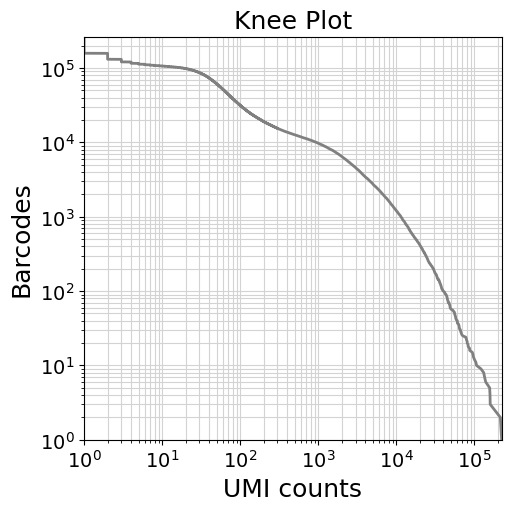

In [5]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Processing technology: {technology}")
    _ = cs_utils.knee_plot(adata_raw, transpose=True, out_path=os.path.join(out_dir, f"knee_plot_{technology}.png"))

In [6]:
# technology_to_umi_cutoff = {}   #!!! update

In [ ]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Inferring empty droplets for technology: {technology}")
    umi_cutoff = technology_to_umi_cutoff[technology]

    parent_dir = technology_to_adata_raw_path[technology].replace(".h5ad", "_raw_dir")
    paths = cs_utils.write_10x_like(adata_raw, parent_dir, gzip_output=True, is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=False)
    raw_tar_file_dir = paths["raw"]

    emptydrops_barcodes_file = os.path.join(data_dir, f"emptydrops_barcodes_{technology}.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    adata_raw.obs["is_empty"] = ~adata_raw.obs.index.isin(emptydrops_cellular_barcodes)

    # adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]   #$ old method
    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    technology_to_adata_raw[technology] = adata_raw

Inferring empty droplets for technology: 10x
📦 Starting EmptyDrops pipeline...
Raw matrix dir:  /home/ruser/work/cellsweep/notebooks/data/parse_10x/adata_10x_raw_raw_dir/raw_gene_bc_matrices/genome 
Filtered barcodes written to:  /home/ruser/work/cellsweep/notebooks/data/parse_10x/emptydrops_barcodes_10x.txt 
✅ EmptyDrops completed successfully.
Inferring empty droplets for technology: parse
📦 Starting EmptyDrops pipeline...
Raw matrix dir:  /home/ruser/work/cellsweep/notebooks/data/parse_10x/adata_parse_raw_raw_dir/raw_gene_bc_matrices/genome 


## cellsweep

In [ ]:
technology_to_adata_cellsweep = {}
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Denoising counts for technology: {technology}")
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{technology}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{technology}.log")
    
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            leiden_resolution = technology_to_leiden_resolution[technology]
            adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
            adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha = 0.9, beta = 0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=True, max_iter=1000, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        print(f"Loading existing cellsweep denoised data for technology: {technology}")
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    
    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    
    technology_to_adata_cellsweep[technology] = adata_cellsweep

Denoising counts for technology: 10x


16:56:37 - INFO - Adata initial shape: (14777, 34183)
16:56:37 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
16:56:37 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
16:56:37 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/cellsweep_10x.log


16:57:13 - DEBUG - Number of parameters in the cellsweep model: 766,804 (alpha: 14,777, beta: 1, p_k: 752,026)
16:57:13 - INFO - Inferring the gene ambient profile from empty droplets.
16:57:13 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
16:57:13 - INFO - Performing Sparse EM with 8 Numba thread(s)
16:57:18 - INFO - EM Iter   1: ll=-537.663 log_delta_p=inf min_alpha=0.1714 mean_alpha=0.8610 median_alpha=0.8657 max_alpha=0.9252 beta=0.102844
16:57:22 - INFO - EM Iter   2: ll=-535.160 log_delta_p=inf min_alpha=0.0099 mean_alpha=0.7969 median_alpha=0.8095 max_alpha=0.9606 beta=0.102906
16:57:22 - INFO - EM Iter   3: ll=-533.388 log_delta_p=-1.3697 min_alpha=0.0013 mean_alpha=0.7335 median_alpha=0.7499 max_alpha=0.9832 beta=0.101601
16:57:22 - INFO - EM Iter   4: ll=-532.295 log_delta_p=-1.9001 min_alpha=0.0002 mean_alpha=0.6816 median_alpha=0.6975 max_alpha=0.9939 beta=0.099881
16:57:22 - INFO - EM Iter   5: ll=-531.628 log_delta_

Denoising counts for technology: parse


16:59:11 - INFO - Adata initial shape: (19053, 34183)
16:59:11 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
16:59:12 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
16:59:12 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/parse_10x/cellsweep_parse.log


16:59:17 - DEBUG - Number of parameters in the cellsweep model: 1,147,093 (alpha: 19,053, beta: 1, p_k: 1,128,039)
16:59:17 - INFO - Inferring the gene ambient profile from empty droplets.
16:59:17 - INFO - adata.obs does not have 'cell_ambient_fraction'. Setting to `cell_ambient_fraction` argument.
16:59:17 - INFO - Performing Sparse EM with 8 Numba thread(s)
16:59:17 - INFO - EM Iter   1: ll=-1930.505 log_delta_p=inf min_alpha=0.7374 mean_alpha=0.8942 median_alpha=0.8953 max_alpha=0.9120 beta=0.100525
16:59:18 - INFO - EM Iter   2: ll=-1928.057 log_delta_p=inf min_alpha=0.5154 mean_alpha=0.8813 median_alpha=0.8851 max_alpha=0.9275 beta=0.100290
16:59:18 - INFO - EM Iter   3: ll=-1926.406 log_delta_p=-1.3825 min_alpha=0.3638 mean_alpha=0.8671 median_alpha=0.8734 max_alpha=0.9492 beta=0.099718
16:59:18 - INFO - EM Iter   4: ll=-1925.245 log_delta_p=-1.8797 min_alpha=0.2707 mean_alpha=0.8533 median_alpha=0.8615 max_alpha=0.9618 beta=0.099011
16:59:18 - INFO - EM Iter   5: ll=-1924.422 l

## Analysis

### Raw vs cellsweep knee plot, scatterplots

Technology: 10x


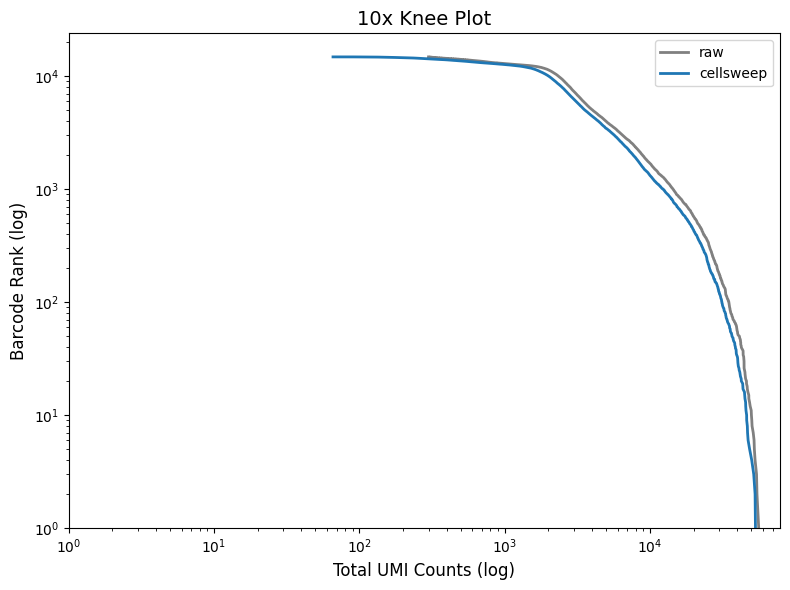

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


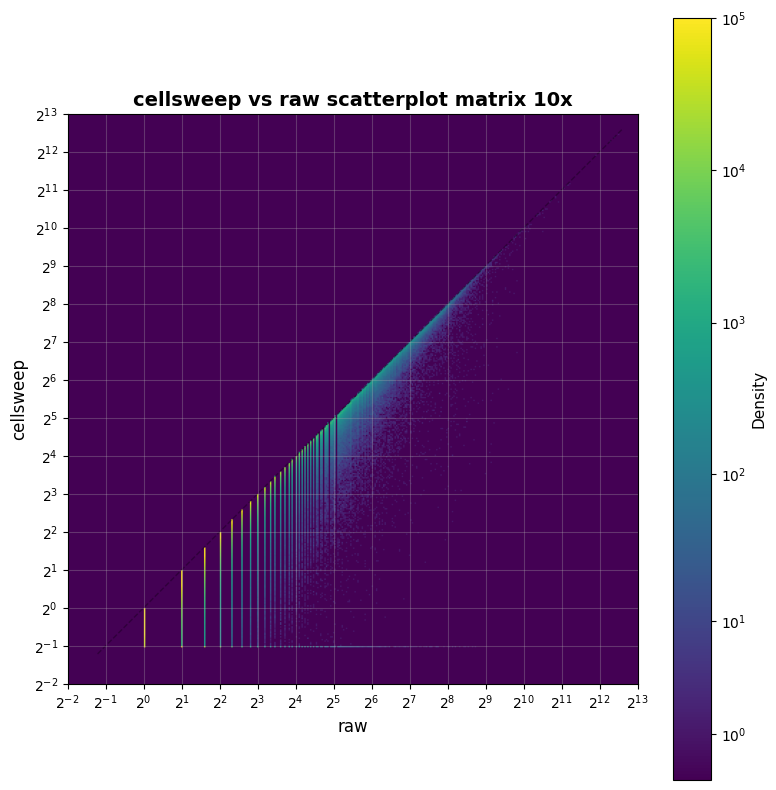

Creating scatterplot...
Calculating scatterplot...


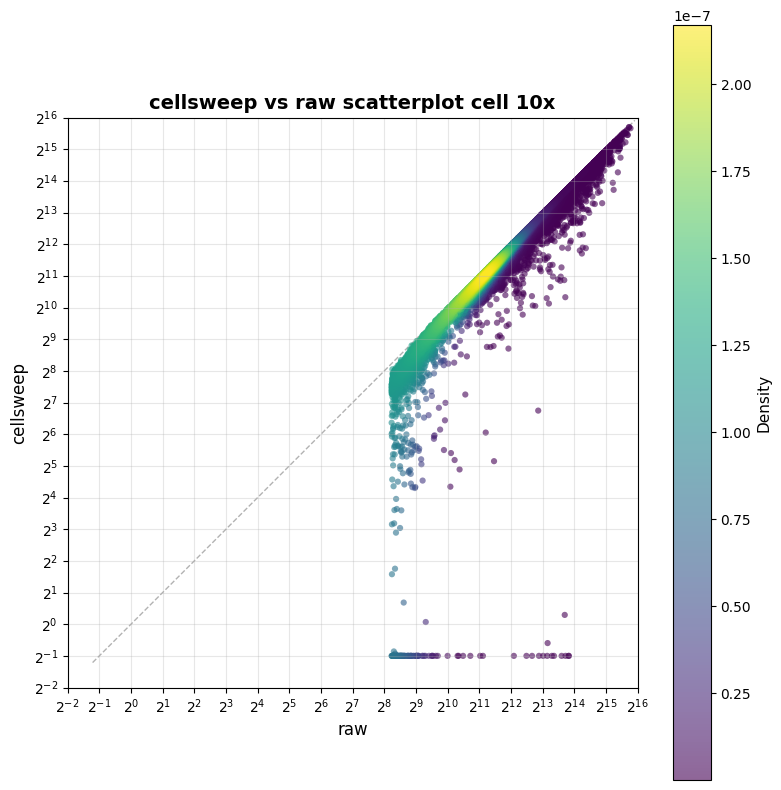

Creating scatterplot...
Calculating scatterplot...


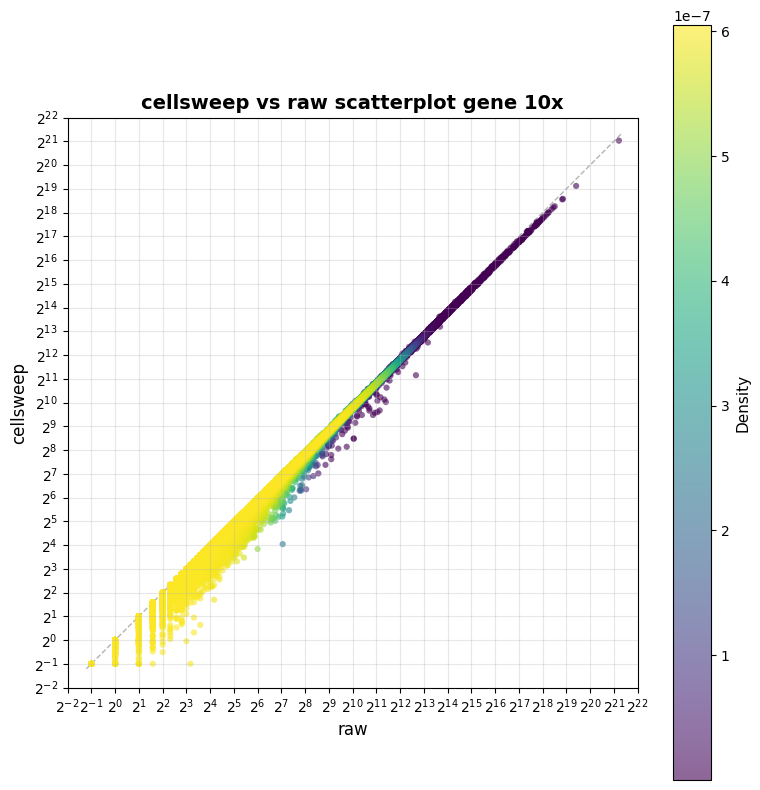

Technology: parse


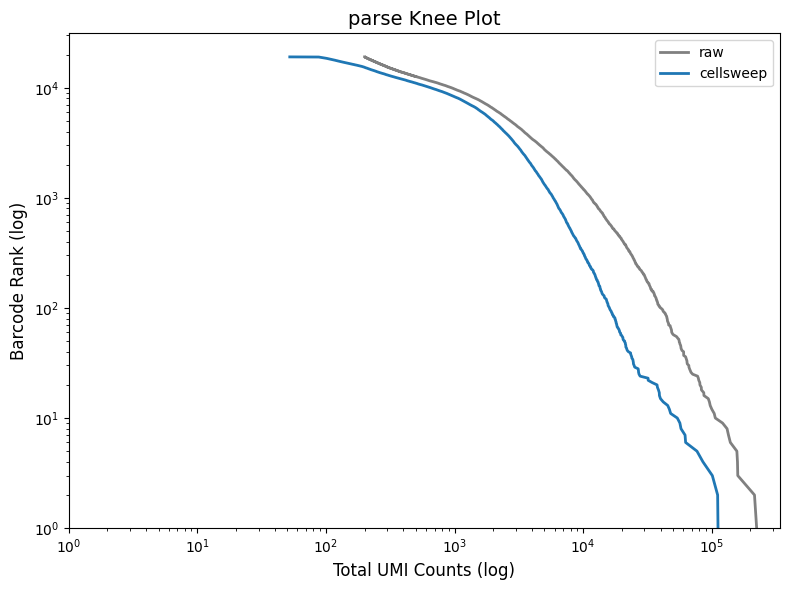

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


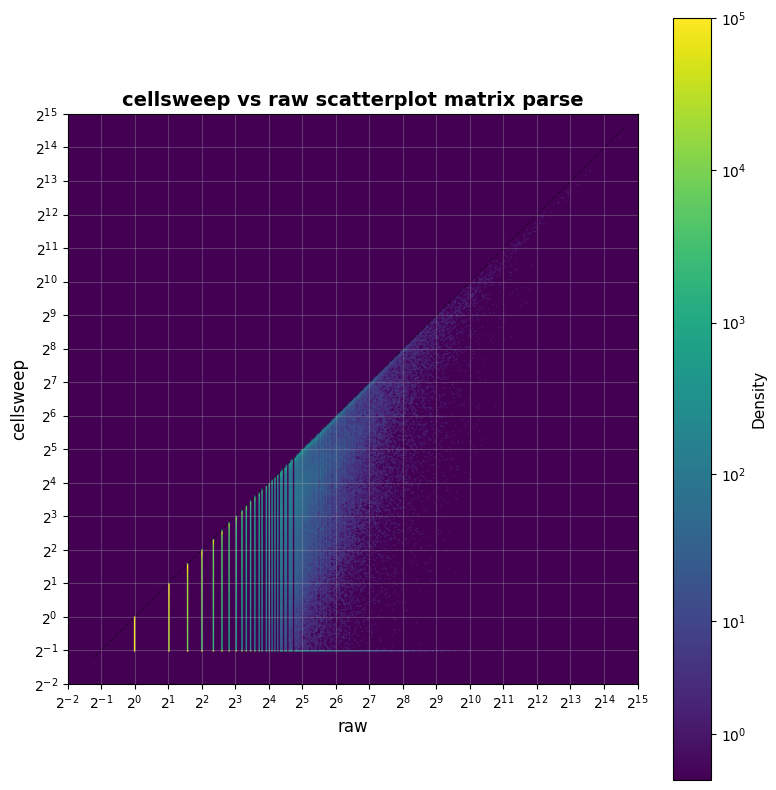

Creating scatterplot...
Calculating scatterplot...


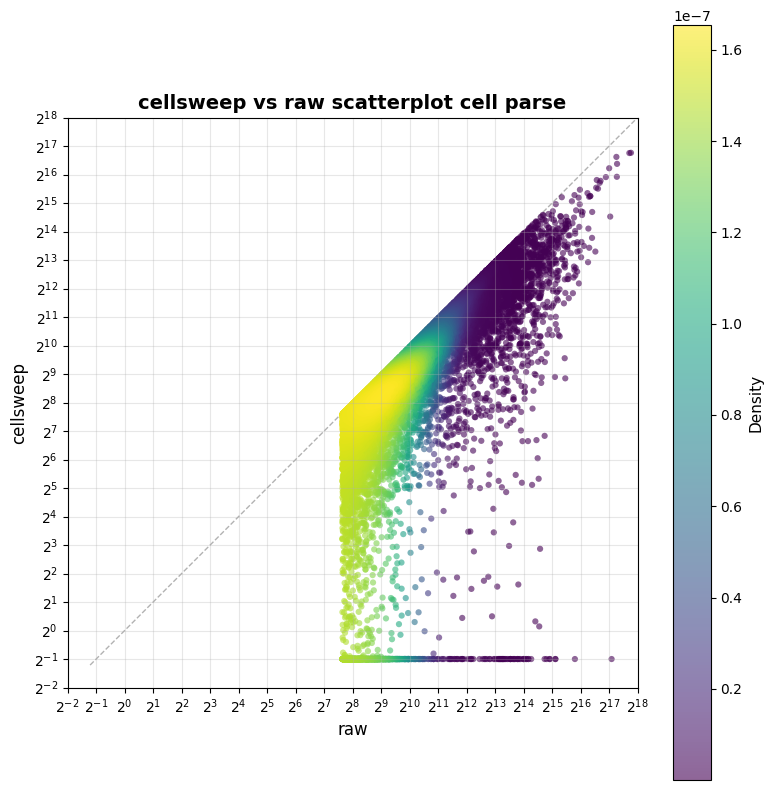

Creating scatterplot...
Calculating scatterplot...


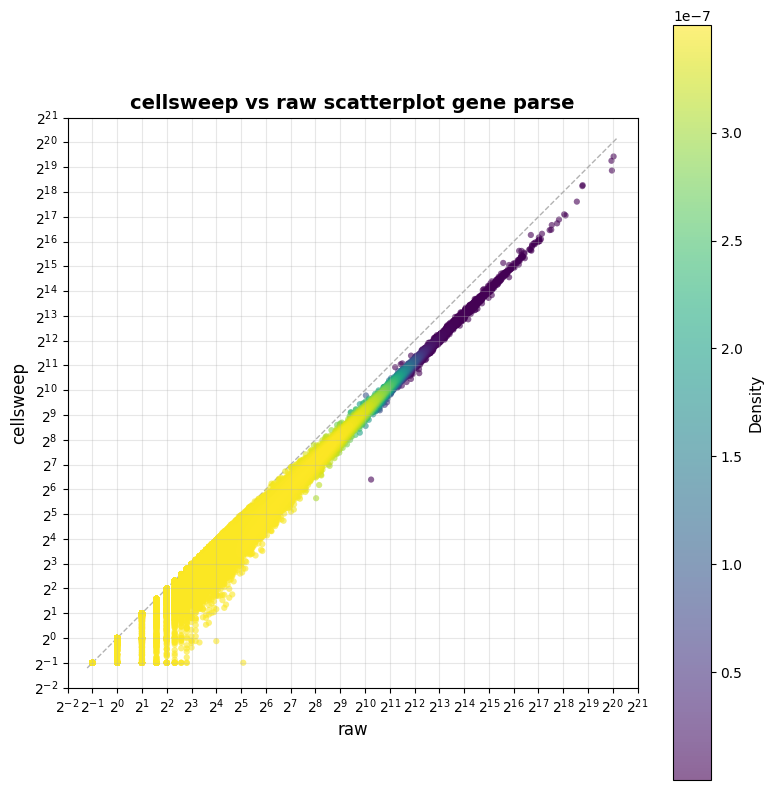

In [9]:
for technology in technologies:
    print(f"Technology: {technology}")
    adata_raw = technology_to_adata_raw[technology]
    adata_cellsweep = technology_to_adata_cellsweep[technology]
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title=f"{technology} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{technology}_knee_plot.png"))

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot matrix {technology}", out_path=os.path.join(out_dir, f"{technology}_matrix_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot cell {technology}", out_path=os.path.join(out_dir, f"{technology}_cell_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot gene {technology}", out_path=os.path.join(out_dir, f"{technology}_gene_expression_scatterplot.png"), show=True)

### Ambient hat per gene scatterplot across technologies

Creating scatterplot...
Calculating scatterplot...


KeyboardInterrupt: 

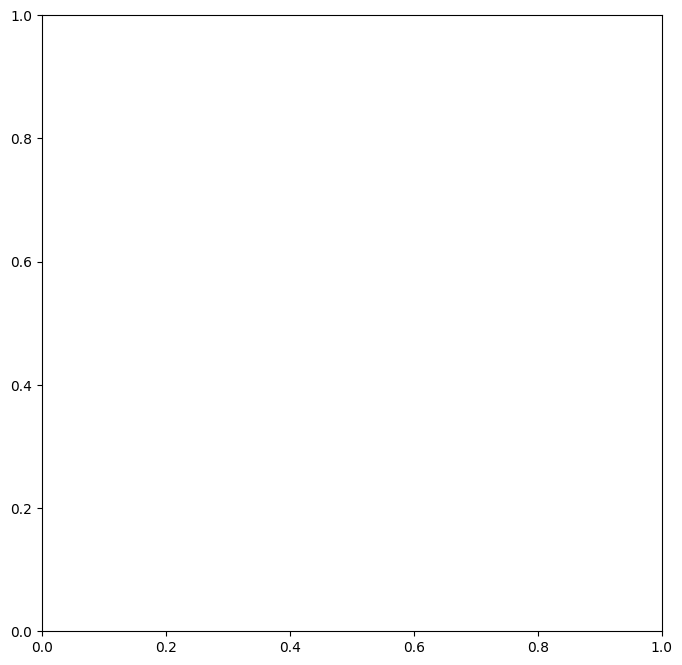

In [10]:
s = technology_to_adata_cellsweep[technology0].var["ambient_hat"]
nonzero_min = s[s > 0].min()
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep[technology0].var["ambient_hat"], technology_to_adata_cellsweep[technology1].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", x_axis=technology0, y_axis=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_ambient_hat_scatterplot.png"), show=True)

### Ambient fraction per cell histogram across technologies

10x cell contamination AUC: 147.76999999999998
parse cell contamination AUC: 190.52999999999997


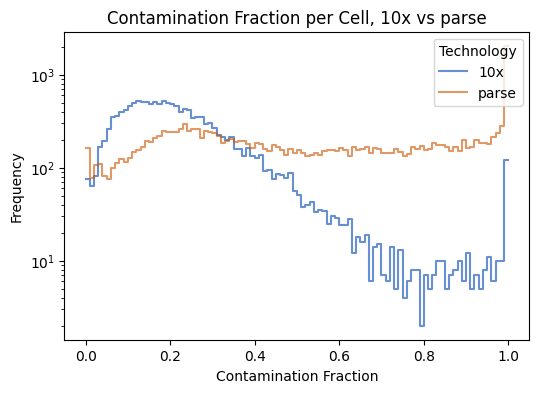

In [ ]:
cs_utils.plot_multi_histogram(technology_to_adata_cellsweep[technology0].obs, technology_to_adata_cellsweep[technology1].obs, plotting_column="alpha_hat", df1_name=technology0, df2_name=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_cell_empty_fraction_scatterplot.png"), show=True)